In [1]:
from tqdm import tqdm
import numpy as np

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Настройка устройства
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


# Подготовка данных (CIFAR-10)

Загрузим CIFAR-10 датасет с нормализацией изображений

In [2]:
# Преобразования для данных
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

# Загрузка датасета
train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=transform)
test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=transform)

# Разделение на train и val
train_indices, val_indices = train_test_split(
    list(range(len(train_dataset_full))),
    test_size=0.2,
    random_state=42,
    shuffle=True
)

train_dataset = Subset(train_dataset_full, train_indices)
val_dataset = Subset(train_dataset_full, val_indices)

print(f'Train size: {len(train_dataset)}')
print(f'Val size: {len(val_dataset)}')
print(f'Test size: {len(test_dataset)}')

100%|██████████| 170M/170M [00:14<00:00, 11.8MB/s]


Train size: 40000
Val size: 10000
Test size: 10000


# 1. Простая CNN

In [3]:
class BasicCNN(nn.Module):
    """Простая CNN с 3 сверточными слоями"""
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # После 3х пулингов: 32->16->8->4, 4*4*64 = 1024
        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# Тест
batch = next(iter(DataLoader(train_dataset, batch_size=8)))
cnn = BasicCNN()
out = cnn(batch[0])
print(f'BasicCNN output shape: {out.shape}')

BasicCNN output shape: torch.Size([8, 10])


# 2. ResNet-18

Реализация ResNet-18 с residual blocks

In [4]:
class ResidualBlock(nn.Module):
    """Residual Block для ResNet"""
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut connection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out += self.shortcut(identity)
        out = F.relu(out)

        return out


class ResNet18(nn.Module):
    """ResNet-18 для CIFAR-10"""
    def __init__(self, num_classes=10):
        super().__init__()

        # Начальный слой
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(64)

        # Residual layers
        self.layer1 = self._make_layer(64, 64, 2, stride=1)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)

        # Average pooling и fully connected
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

# Тест
resnet = ResNet18()
out = resnet(batch[0])
print(f'ResNet18 output shape: {out.shape}')
print(f'ResNet18 parameters: {sum(p.numel() for p in resnet.parameters())}')

ResNet18 output shape: torch.Size([8, 10])
ResNet18 parameters: 11178762


# 3. Класс для тренировки

In [5]:
class Trainer:
    """Тренер для обучения моделей"""
    def __init__(self, model, config):
        self.model = model.to(device)
        self.config = config
        self.device = device

        self.optimizer = Adam(self.model.parameters(), lr=config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()

        # Для сохранения истории
        self.train_losses = []
        self.train_accs = []
        self.val_losses = []
        self.val_accs = []

    def setup_dataloaders(self, batch_size=128):
        self.train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=0
        )
        self.val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0
        )
        self.test_loader = DataLoader(
            test_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0
        )

    def train_step(self):
        self.model.train()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.train_loader, desc='Train'):
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        self.scheduler.step()

        avg_loss = total_loss / len(self.train_loader)
        avg_acc = correct / total_samples * 100

        self.train_losses.append(avg_loss)
        self.train_accs.append(avg_acc)

        return avg_loss, avg_acc

    def val_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        with torch.no_grad():
            for images, labels in tqdm(self.val_loader, desc='Val'):
                images, labels = images.to(self.device), labels.to(self.device)

                outputs = self.model(images)
                loss = self.loss_function(outputs, labels)

                total_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total_samples += labels.size(0)

        avg_loss = total_loss / len(self.val_loader)
        avg_acc = correct / total_samples * 100

        self.val_losses.append(avg_loss)
        self.val_accs.append(avg_acc)

        return avg_loss, avg_acc

    def test(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        with torch.no_grad():
            for images, labels in tqdm(self.test_loader, desc='Test'):
                images, labels = images.to(self.device), labels.to(self.device)

                outputs = self.model(images)
                loss = self.loss_function(outputs, labels)

                total_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total_samples += labels.size(0)

        avg_loss = total_loss / len(self.test_loader)
        avg_acc = correct / total_samples * 100

        return avg_loss, avg_acc

    def train(self):
        for epoch in range(self.config['num_epochs']):
            train_loss, train_acc = self.train_step()
            val_loss, val_acc = self.val_step()

            print(f'Epoch {epoch + 1}/{self.config["num_epochs"]}')
            print(f'  Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%')
            print(f'  Val Loss:   {val_loss:.4f}, Acc: {val_acc:.2f}%')
            print()

# 4. Тренировка моделей

In [6]:
config = {
    'num_epochs': 15,
    'lr': 0.001,
    'batch_size': 128
}

print('=' * 60)
print('Training BasicCNN')
print('=' * 60)

cnn_trainer = Trainer(BasicCNN(), config)
cnn_trainer.setup_dataloaders(config['batch_size'])
cnn_trainer.train()

cnn_test_loss, cnn_test_acc = cnn_trainer.test()
print(f'\nBasicCNN Test - Loss: {cnn_test_loss:.4f}, Acc: {cnn_test_acc:.2f}%')

Training BasicCNN


Val: 100%|██████████| 79/79 [00:03<00:00, 21.26it/s]


Epoch 1/15
  Train Loss: 1.5779, Acc: 43.03%
  Val Loss:   1.3321, Acc: 52.72%



Val: 100%|██████████| 79/79 [00:03<00:00, 23.94it/s]


Epoch 2/15
  Train Loss: 1.2025, Acc: 56.97%
  Val Loss:   1.1287, Acc: 59.18%



...

Epoch 14/15
  Train Loss: 0.5994, Acc: 79.11%
  Val Loss:   0.8111, Acc: 72.22%



Val: 100%|██████████| 79/79 [00:02<00:00, 31.63it/s]


Epoch 15/15
  Train Loss: 0.5984, Acc: 79.31%
  Val Loss:   0.8111, Acc: 72.25%



Test: 100%|██████████| 79/79 [00:02<00:00, 31.53it/s]


BasicCNN Test - Loss: 0.8342, Acc: 71.97%


In [7]:
print('=' * 60)
print('Training ResNet18')
print('=' * 60)

resnet_trainer = Trainer(ResNet18(), config)
resnet_trainer.setup_dataloaders(config['batch_size'])
resnet_trainer.train()

resnet_test_loss, resnet_test_acc = resnet_trainer.test()
print(f'\nResNet18 Test - Loss: {resnet_test_loss:.4f}, Acc: {resnet_test_acc:.2f}%')

Training ResNet18


Val: 100%|██████████| 79/79 [00:04<00:00, 16.68it/s]


Epoch 1/15
  Train Loss: 1.3933, Acc: 48.73%
  Val Loss:   1.0729, Acc: 61.17%



Val: 100%|██████████| 79/79 [00:04<00:00, 17.14it/s]


Epoch 2/15
  Train Loss: 0.9103, Acc: 67.51%
  Val Loss:   1.1419, Acc: 62.13%



...

Epoch 14/15
  Train Loss: 0.0208, Acc: 99.77%
  Val Loss:   0.5928, Acc: 84.66%



Val: 100%|██████████| 79/79 [00:04<00:00, 16.86it/s]


Epoch 15/15
  Train Loss: 0.0189, Acc: 99.84%
  Val Loss:   0.6011, Acc: 84.79%



Test: 100%|██████████| 79/79 [00:05<00:00, 15.35it/s]


ResNet18 Test - Loss: 0.6162, Acc: 84.40%


# 5. Сравнение моделей (Графики)

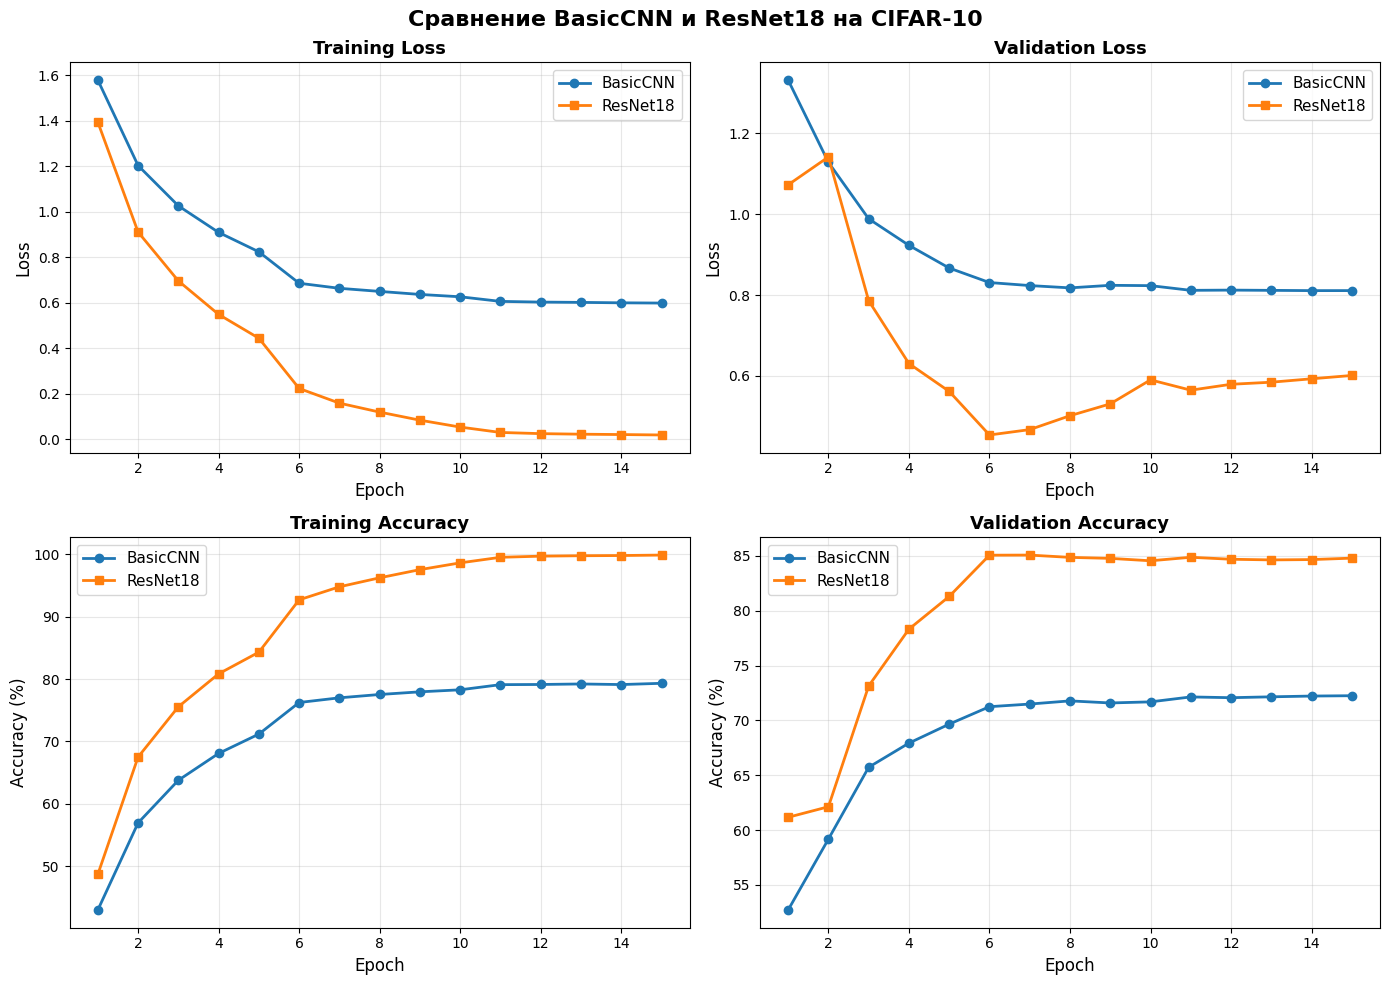

Graph saved as model_comparison.png


In [8]:
# Создание фигуры с 4 графиками
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Сравнение BasicCNN и ResNet18 на CIFAR-10', fontsize=16, fontweight='bold')

epochs = range(1, config['num_epochs'] + 1)

# 1. Training Loss
axes[0, 0].plot(epochs, cnn_trainer.train_losses, label='BasicCNN', marker='o', linewidth=2)
axes[0, 0].plot(epochs, resnet_trainer.train_losses, label='ResNet18', marker='s', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Training Loss', fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# 2. Validation Loss
axes[0, 1].plot(epochs, cnn_trainer.val_losses, label='BasicCNN', marker='o', linewidth=2)
axes[0, 1].plot(epochs, resnet_trainer.val_losses, label='ResNet18', marker='s', linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].set_title('Validation Loss', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# 3. Training Accuracy
axes[1, 0].plot(epochs, cnn_trainer.train_accs, label='BasicCNN', marker='o', linewidth=2)
axes[1, 0].plot(epochs, resnet_trainer.train_accs, label='ResNet18', marker='s', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Accuracy (%)', fontsize=12)
axes[1, 0].set_title('Training Accuracy', fontsize=13, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# 4. Validation Accuracy
axes[1, 1].plot(epochs, cnn_trainer.val_accs, label='BasicCNN', marker='o', linewidth=2)
axes[1, 1].plot(epochs, resnet_trainer.val_accs, label='ResNet18', marker='s', linewidth=2)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1, 1].set_title('Validation Accuracy', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Graph saved as model_comparison.png')

# 6. Финальное сравнение

In [9]:
print('\n' + '='*60)
print('ФИНАЛЬНОЕ СРАВНЕНИЕ')
print('='*60)

print('\nBasicCNN:')
print(f'  - Параметров: {sum(p.numel() for p in BasicCNN().parameters()):,}')
print(f'  - Test Loss: {cnn_test_loss:.4f}')
print(f'  - Test Accuracy: {cnn_test_acc:.2f}%')
print(f'  - Best Val Acc: {max(cnn_trainer.val_accs):.2f}%')

print('\nResNet18:')
print(f'  - Параметров: {sum(p.numel() for p in ResNet18().parameters()):,}')
print(f'  - Test Loss: {resnet_test_loss:.4f}')
print(f'  - Test Accuracy: {resnet_test_acc:.2f}%')
print(f'  - Best Val Acc: {max(resnet_trainer.val_accs):.2f}%')

print('\nВыводы:')
if resnet_test_acc > cnn_test_acc:
    diff = resnet_test_acc - cnn_test_acc
    print(f'✓ ResNet18 превосходит BasicCNN на {diff:.2f}% по точности на тесте')
else:
    diff = cnn_test_acc - resnet_test_acc
    print(f'✓ BasicCNN превосходит ResNet18 на {diff:.2f}% по точности на тесте')

resnet_params = sum(p.numel() for p in ResNet18().parameters())
cnn_params = sum(p.numel() for p in BasicCNN().parameters())
ratio = resnet_params / cnn_params
print(f'✓ ResNet18 имеет в {ratio:.1f}x больше параметров, чем BasicCNN')

print('\n' + '='*60)


ФИНАЛЬНОЕ СРАВНЕНИЕ

BasicCNN:
  - Параметров: 156,074
  - Test Loss: 0.8342
  - Test Accuracy: 71.97%
  - Best Val Acc: 72.25%

ResNet18:
  - Параметров: 11,178,762
  - Test Loss: 0.6162
  - Test Accuracy: 84.40%
  - Best Val Acc: 85.07%

Выводы:
✓ ResNet18 превосходит BasicCNN на 12.43% по точности на тесте
✓ ResNet18 имеет в 71.6x больше параметров, чем BasicCNN

